# Chapter 16: Real life full project

### 16.1. Preparation of the data
> ###### 16.1.1. Importation of the data
> ###### 16.1.2. Features engineering
> ###### 16.1.3. Tain, test and validation sets	

### 16.2. Modelling the strategy
> ###### 16.2.1. Find the best assets
> ###### 16.2.2. Combine the algorithms	
> ###### 16.2.3. Apply portfolio management technics

### 16.3. Find optimal take profit, stop loss and leverage
> ###### 16.3.1. Optimal take profit	
> ###### 16.3.2. Optimal stop loss
> ###### 16.3.3. Optimal leverage


In [20]:
!pip install xgboost
!pip install seaborn


In [2]:
import numpy as np
import pandas as pd
import MetaTrader5 as mt5
import time
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
mt5.initialize()
import ta

In [29]:
import pandas as pd
import yfinance as yf
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")
import matplotlib as mpl


def backtest_static_portfolio(weights, database, ben="^GSPC", timeframe=252, CR=False):
    """
    -----------------------------------------------------------------------------
    | Output: Beta CAPM metric                                                  |
    -----------------------------------------------------------------------------
    | Inputs: - weights (type 1d array numpy): weights of the portfolio         |
    |         - database (type dataframe pandas): Returns of the asset          |
    |         - ben (type string): Name of the benchmark                        |
    |         - timeframe (type int): annualization factor                      |
    -----------------------------------------------------------------------------
    """
    import pandas as pd
    import yfinance as yf
    import numpy as np
    from scipy.optimize import minimize
    import matplotlib.pyplot as plt


    # Compute the portfolio
    portfolio = np.multiply(database,np.transpose(weights))
    portfolio = portfolio.sum(axis=1)
    columns = database.columns
    columns = [col for col in columns]

    ######################### COMPUTE THE BETA ##################################
    # Importation of benchmark
    benchmark = yf.download(ben)["Adj Close"].pct_change(1).dropna()

    # Concat the asset and the benchmark
    join = pd.concat((portfolio, benchmark), axis=1).dropna()

    # Covariance between the asset and the benchmark
    cov = np.cov(join, rowvar=False)[0][1]

    # Compute the variance of the benchmark
    var = np.cov(join, rowvar=False)[1][1]

    beta = cov/var


    ######################### COMPUTE THE ALPHA #################################
    # Mean of returns for the asset
    mean_stock_return = join.iloc[:,0].mean()*timeframe

    # Mean of returns for the market
    mean_market_return = join.iloc[:,1].mean()*timeframe

    # Alpha
    alpha = mean_stock_return - beta*mean_market_return


    ######################### COMPUTE THE SHARPE ################################
    mean = portfolio.mean() * timeframe
    std = portfolio.std() * np.sqrt(timeframe)
    Sharpe = mean/std


    ######################### COMPUTE THE SORTINO ###############################
    downward = portfolio[portfolio<0]
    std_downward = downward.std() * np.sqrt(timeframe)
    Sortino = mean/std_downward


    ######################### COMPUTE THE DRAWDOWN ###############################
    # Compute the cumulative product returns
    cum_rets = (portfolio+1).cumprod()

    # Compute the running max
    running_max = np.maximum.accumulate(cum_rets.dropna())
    running_max[running_max < 1] = 1

    # Compute the drawdown
    drawdown = ((cum_rets)/running_max - 1)
    min_drawdon = -drawdown.min()


    ######################### COMPUTE THE VaR ##################################
    theta = 0.01
    # Number of simulations
    n = 100000

    # Find the values for theta% error threshold
    t = int(n*theta)

    # Create a vector with n simulations of the normal law
    vec = pd.DataFrame(np.random.normal(mean, std, size=(n,)),
    columns = ["Simulations"])

    # Orderer the values and find the theta% value
    VaR = -vec.sort_values(by="Simulations").iloc[t].values[0]


    ######################### COMPUTE THE cVaR #################################
    cVaR = -vec.sort_values(by="Simulations").iloc[0:t,:].mean().values[0]

    ######################### COMPUTE THE RC ###################################
    if CR:
        # Find the number of the asset in the portfolio
        l = len(weights)

        # Compute the risk contribution of each asset
        crs = []
        for i in range(l):
            # Importation of benchmark
            benchmark = yf.download(ben)["Adj Close"].pct_change(1).dropna()

            # Concat the asset and the benchmark
            join = pd.concat((database.iloc[:,i], benchmark), axis=1).dropna()

            # Covariance between the asset and the benchmark
            cov = np.cov(join, rowvar=False)[0][1]

            # Compute the variance of the benchmark
            var = np.cov(join, rowvar=False)[1][1]
            beta_s = cov/var
            cr = beta_s * weights[i]
            crs.append(cr)
            crs_ = crs/np.sum(crs) # Normalizing by the sum of the risk contribution

    ######################### PLOT THE RESULTS #################################
    print(f"""
    -----------------------------------------------------------------------------
    Portfolio: {columns}
    -----------------------------------------------------------------------------
    Beta: {np.round(beta, 3)} \t Alpha: {np.round(alpha*100, 2)} %\t \
    Sharpe: {np.round(Sharpe, 3)} \t Sortino: {np.round(Sortino, 3)}
    -----------------------------------------------------------------------------
    VaR: {np.round(VaR*100, 2)} %\t cVaR: {np.round(cVaR*100, 2)} % \t \
    VaR/cVaR: {np.round(cVaR/VaR, 3)} \t drawdown: {np.round(min_drawdon*100, 2)} %
    -----------------------------------------------------------------------------
    """)

    plt.figure(figsize=(15,8))
    plt.plot(join.iloc[:,0].cumsum()*100, color="#035593", linewidth=3)
    plt.plot(join.iloc[:,1].cumsum()*100, color="#068C72", linewidth=3)
    plt.title("CUMULTATIVE RETURN", size=15)
    plt.ylabel("Cumulative return %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.legend(["Strategy", "Benchmark"])
    plt.savefig(f'Cum.svg', format='svg', dpi=1200)
    plt.show()

    plt.figure(figsize=(15,8))
    plt.fill_between(drawdown.index, drawdown*100, 0, color="#CE5151")
    plt.plot(drawdown.index,drawdown*100, color="#930303", linewidth=1.5)
    plt.title("DRAWDOWN", size=15)
    plt.ylabel("Drawdown %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.savefig(f'drawdown.svg', format='svg', dpi=1200)
    plt.show()



    if CR:
        plt.figure(figsize=(15,8))
        plt.scatter(columns, crs_, linewidth=3, color = "#B96553")
        plt.axhline(0, color="#53A7B9")
        plt.grid(axis="x")
        plt.title("RISK CONTRIBUTION PORTFOLIO", size=15)
        plt.xlabel("Assets")
        plt.ylabel("Risk contribution")
        plt.xticks(size=15,fontweight="bold")
        plt.yticks(size=15,fontweight="bold")
        plt.savefig(f'CR.svg', format='svg', dpi=1200)
        plt.show()
        plt.show()


def backtest_dynamic_portfolio(dfc, ben="^GSPC", timeframe=252):
  """
  -----------------------------------------------------------------------------
  | Output: Beta CAPM metric                                                  |
  -----------------------------------------------------------------------------
  | Inputs: - weights (type 1d array numpy): weights of the portfolio         |
  |         - database (type dataframe pandas): Returns of the asset          |
  |         - ben (type string): Name of the benchmark                        |
  |         - timeframe (type int): annualization factor                      |
  -----------------------------------------------------------------------------
  """
  import pandas as pd
  import yfinance as yf
  import numpy as np
  from scipy.optimize import minimize
  import matplotlib.pyplot as plt
  import matplotlib as mpl
  import matplotlib.pyplot as plt

  from matplotlib import cycler


  font = {'weight' : 'bold', "size":"300"}
  plt.rc('font', **font)

  # Maybe from series to dataframe
  if str(type(dfc)) == "<class 'pandas.core.series.Series'>":
    dfc = pd.DataFrame(dfc)
    
  # find the returns
  if len(dfc.columns)==1:
    dfc.columns=["returns"]
    

  # CREATE DAILY RETURNS
  portfolio = dfc["returns"]
  if portfolio.index.name != "Time":
      portfolio.index.name = "Time"


  portfolio = portfolio.reset_index(drop=False)
  portfolio.groupby(pd.Grouper(key='Time',freq='d')).sum()
  portfolio = portfolio.set_index("Time")
  ######################### COMPUTE THE BETA ##################################
  # Importation of benchmark
  benchmark = yf.download(ben)["Adj Close"].pct_change(1).dropna()

  # Concat the asset and the benchmark
  join = pd.concat((portfolio, benchmark), axis=1).dropna()

  # Covariance between the asset and the benchmark
  cov = np.cov(join, rowvar=False)[0][1]

  # Compute the variance of the benchmark
  var = np.cov(join, rowvar=False)[1][1]

  beta = cov/var


  ######################### COMPUTE THE ALPHA #################################
  # Mean of returns for the asset
  mean_stock_return = join.iloc[:,0].mean()*timeframe

  # Mean of returns for the market
  mean_market_return = join.iloc[:,1].mean()*timeframe

  # Alpha
  alpha = mean_stock_return - beta*mean_market_return


  ######################### COMPUTE THE SHARPE ################################
  mean = portfolio.mean() * np.sqrt(timeframe)
  std = portfolio.std() 
  Sharpe = (mean/std)[0]


  ######################### COMPUTE THE SORTINO ###############################
  downward = portfolio[portfolio<0]* np.sqrt(timeframe)
  std_downward = downward.std()
  Sortino = (mean/std_downward)[0]


  ######################### COMPUTE THE DRAWDOWN ###############################
  # Compute the cumulative product returns
  coef_rets = (portfolio+1).cumprod()
  cum_rets = coef_rets-1

  # Compute the running max
  running_max = np.maximum.accumulate(coef_rets.dropna())
  #running_max[running_max < 1] = 1

  # Compute the drawdown
  drawdown = ((coef_rets/running_max) - 1)
  min_drawdon = (-drawdown.min())[0]


  ######################### COMPUTE THE VaR ##################################
  theta = 0.01
  # Number of simulations
  n = 100000
  
  # Find the values for theta% error threshold
  t = int(n*theta)

  # Create a vector with n simulations of the normal law
  vec = pd.DataFrame(np.random.normal(mean, std, size=(n,)),columns = ["Simulations"])
  
  # Orderer the values and find the theta% value
  VaR = -vec.sort_values(by="Simulations").iloc[t].values[0]


  ######################### COMPUTE THE cVaR #################################
  cVaR = -vec.sort_values(by="Simulations").iloc[0:t,:].mean().values[0]

  ######################### TIME UNDERWATER ##################################
  tuw = len(drawdown[drawdown<0]) / len(drawdown)

  ######################### PLOT THE RESULTS #################################
  print(f"""
    -----------------------------------------------------------------------------
    Beta: {np.round(beta, 3)} \t Alpha: {np.round(alpha*100, 2)} %\t \
    Sharpe: {np.round(Sharpe, 3)} \t Sortino: {np.round(Sortino, 3)}
  -----------------------------------------------------------------------------
    VaR: {np.round(VaR*100, 2)} %\t cVaR: {np.round(cVaR*100, 2)} % \t \
    VaR/cVaR: {np.round(cVaR/VaR, 3)} \t drawdown: {np.round(min_drawdon*100, 2)} %
  -----------------------------------------------------------------------------""")
  

  plt.figure(figsize=(15,8))
  plt.plot(join.iloc[:,0].cumsum()*100, color="#035593", linewidth=3)
  plt.plot(join.iloc[:,1].cumsum()*100, color="#068C72", linewidth=3)
  plt.title("CUMULTATIVE RETURN", size=15)
  plt.ylabel("Cumulative return %", size=15)
  plt.xticks(size=15,fontweight="bold")
  plt.yticks(size=15,fontweight="bold")
  plt.legend(["Strategy", "Benchmark"])
  plt.show()

  plt.figure(figsize=(15,8))
  plt.fill_between(drawdown.index, drawdown.iloc[:,0]*100, 0, color="#CE5151")
  plt.plot(drawdown.index,drawdown.iloc[:,0]*100, color="#930303", linewidth=3)
  plt.title("DRAWDOWN", size=15)
  plt.ylabel("Drawdown %", size=15)
  plt.xticks(size=15,fontweight="bold")
  plt.yticks(size=15,fontweight="bold")
  plt.show()

def backtest_tpsl_portfolio(dfc, ben="^GSPC", timeframe=252):

    """
    -----------------------------------------------------------------------------
    | Output: Backtest                                                          |
    -----------------------------------------------------------------------------
    | Inputs: - database (type dataframe pandas): data of the asset          |
    |         - ben (type string): Name of the benchmark                        |
    |         - timeframe (type int): annualization factor                      |
    -----------------------------------------------------------------------------
    """
    # COMPUTE TRADE LIFETIME
    sum_dates = dfc["duration"]
    seconds = np.round(np.mean(list(sum_dates.loc[sum_dates!=0])).total_seconds())
    minutes = seconds//60
    minutes_left = int(minutes%60)
    hours = int(minutes//60)

    # CREATE DAILY RETURNS
    portfolio = dfc["returns"]
    if portfolio.index.name != "Time":
        portfolio.index.name = "Time"


    portfolio = portfolio.reset_index(drop=False)
    portfolio.groupby(pd.Grouper(key='Time',freq='d')).sum()
    portfolio = portfolio.set_index("Time")

    ######################### COMPUTE THE BETA ##################################
    # Importation of benchmark
    benchmark = yf.download(ben)["Adj Close"].pct_change(1).dropna()

    # Concat the asset and the benchmark
    join = pd.concat((portfolio[["returns"]], benchmark), axis=1).dropna()

    # Covariance between the asset and the benchmark
    cov = np.cov(join, rowvar=False)[0][1]

    # Compute the variance of the benchmark
    var = np.cov(join, rowvar=False)[1][1]

    beta = cov/var

    ######################### COMPUTE THE ALPHA #################################
    # Mean of returns for the asset
    mean_stock_return = join.iloc[:,0].mean()*timeframe

    # Mean of returns for the market
    mean_market_return = join.iloc[:,1].mean()*timeframe

    # Alpha
    alpha = mean_stock_return - beta*mean_market_return

    ######################### COMPUTE THE SHARPE ################################
    mean = portfolio.mean() * np.sqrt(timeframe)
    std = portfolio.std() 
    Sharpe = (mean/std)[0]


    ######################### COMPUTE THE SORTINO ###############################
    downward = portfolio[portfolio<0]* np.sqrt(timeframe)
    std_downward = downward.std()
    Sortino = (mean/std_downward)[0]


    ######################### COMPUTE THE DRAWDOWN ###############################
    # Compute the cumulative product returns
    coef_rets = (portfolio+1).cumprod()
    cum_rets = coef_rets-1

    # Compute the running max
    running_max = np.maximum.accumulate(coef_rets.dropna())
    #running_max[running_max < 1] = 1

    # Compute the drawdown
    drawdown = ((coef_rets/running_max) - 1)
    min_drawdon = (-drawdown.min())[0]

    ######################### COMPUTE THE VaR ##################################
    theta = 0.01
    # Number of simulations
    n = 100000

    # Find the values for theta% error threshold
    t = int(n*theta)

    # Create a vector with n simulations of the normal law
    vec = pd.DataFrame(np.random.normal(mean, std, size=(n,)),columns = ["Simulations"])

    # Orderer the values and find the theta% value
    VaR = -vec.sort_values(by="Simulations").iloc[t].values[0]


    ######################### COMPUTE THE cVaR #################################
    cVaR = -vec.sort_values(by="Simulations").iloc[0:t,:].mean().values[0]

    ######################### TIME UNDERWATER ##################################
    tuw = len(drawdown[drawdown["returns"]<0]) / len(drawdown)
    
    ######################### PLOT THE RESULTS #################################
    print(f"""
    -----------------------------------------------------------------------------
    Beta: {np.round(beta, 3)} \t Alpha: {np.round(alpha*100, 2)} %\t \
    AVERAGE TRADE LIFETIME: {hours}H {minutes_left}min
    -----------------------------------------------------------------------------
    VaR: {np.round(VaR*100, 2)} %\t cVaR: {np.round(cVaR*100, 2)} % \t \
    TUW: {np.round(tuw*100,2)}%  \t drawdown: {np.round(min_drawdon*100, 2)} %
    -----------------------------------------------------------------------------""")

    plt.figure(figsize=(15,8))
    plt.plot(cum_rets*100, color="#035593", linewidth=3)
    plt.plot(join.iloc[:,1].cumsum()*100, color="#068C72", linewidth=3)
    plt.title("CUMULTATIVE RETURN", size=15)
    plt.ylabel("Cumulative return %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.legend(["Strategy", "Benchmark"])
    plt.show()

    plt.figure(figsize=(15,8))
    plt.fill_between(drawdown.index, drawdown.iloc[:,0]*100, 0, color="#CE5151")
    plt.plot(drawdown.index,drawdown.iloc[:,0]*100, color="#930303", linewidth=3)


    plt.title("DRAWDOWN", size=15)
    plt.ylabel("Drawdown %", size=15)
    plt.xticks(size=15,fontweight="bold")
    plt.yticks(size=15,fontweight="bold")
    plt.show()






### 16.1.1. Importation of the data

In [3]:
# INITIALIZE THE DEVICE
# Create empty lists
symbols = []
sectors = []
descriptions = []

# Get the information for all symbol
symbols_information = mt5.symbols_get()

# Tuple to list
symbols_information_list = list(symbols_information)

# Extract the name of the symbol
for element in symbols_information_list:
    if list(element)[-3] in ('USDJPYm','BTCUSDm','XAUUSDm'):
        symbols.append(list(element)[-3])
        sectors.append(list(element)[-1].split("\\")[0])
        descriptions.append(list(element)[-7])
    
# Create a dataframe
informations = pd.DataFrame([symbols, sectors, descriptions], index=["Symbol", "Sector", "Description"]).transpose()


# Create empty list
spread = []

# Computze the spread
for symbol in informations["Symbol"]:
    try:
        ask =  mt5.symbol_info_tick(symbol).ask
        bid =  mt5.symbol_info_tick(symbol).bid
        spread.append((ask - bid) / bid )
        
    except:
        spread.append(None)

# Take the assets with the spread < 0.07%spread = 0.35
informations["Spread"] = spread
lowest_spread_asset = informations.dropna().loc[informations["Spread"]<0.0035]
#lowest_spread_asset = informations

In [4]:
informations

,Symbol,Sector,Description,Spread
0,BTCUSDm,Standard,Bitcoin vs US Dollar,0.000189
1,USDJPYm,Standard,US Dollar vs Japanese Yen,0.000122
2,XAUUSDm,Standard,Gold vs US Dollar,0.000048


In [5]:
lowest_spread_asset

,Symbol,Sector,Description,Spread
0,BTCUSDm,Standard,Bitcoin vs US Dollar,0.000189
1,USDJPYm,Standard,US Dollar vs Japanese Yen,0.000122
2,XAUUSDm,Standard,Gold vs US Dollar,0.000048


In [6]:
def get_data(symbol, n, timeframe=mt5.TIMEFRAME_H4):
    """ Function which returns the data of the symbol"""

    # Initialize MetaTrader device
    mt5.initialize()
    
    # Put the data in a dataframe
    utc_from = datetime.now()+timedelta(hours=1)
    rates = mt5.copy_rates_from(symbol, timeframe, utc_from,n) 
    rates_frame = pd.DataFrame(rates)
    
    # Convert time in seconds into the datetime format 
    rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
    rates_frame['time'] =  pd.to_datetime(rates_frame['time'], format='%Y-%m-%d')
    rates_frame = rates_frame.set_index('time')
    
    return rates_frame

### 16.1.2. Features engineering 

In [7]:
def features_engineering(df):
    """ This function which creates all the necessary sets for the algorithms"""

    # Allows the variables to be call outside the function
    global X_train
    global X_test
    global y_train_reg
    global y_train_cla 
    global X_train_scaled 
    global X_test_scaled
    global split_train_test
    global split_test_valid
    global X_valid
    global X_valid_scaled
    global X_train_pca
    global X_test_pca
    global X_val_pca


    # Create ours own metrics to compute the strategy returns
    df["returns"] = ((df["close"] - df["close"].shift(1)) / df["close"])
    df["sLow"] = ((df["low"] - df["close"].shift(1)) / df["close"].shift(1))
    df["sHigh"] = ((df["high"] - df["close"].shift(1)) / df["close"].shift(1))

    # Features engineering
    df["returns t-1"] = df[["returns"]].shift(1)

    # Mean of returns
    df["mean returns 15"] = df[["returns"]].rolling(15).mean().shift(1)
    df["mean returns 60"] = df[["returns"]].rolling(60).mean().shift(1)

    # Volatility of returns
    df["volatility returns 15"] = df[["returns"]].rolling(15).std().shift(1)
    df["volatility returns 60"] = df[["returns"]].rolling(60).std().shift(1)

    # Drop missing values
    df = df.dropna()
    
    # Percentage train set
    split = int(0.80*len(df))
   

   
    list_x = ["returns t-1", "mean returns 15", "mean returns 60",
                  "volatility returns 15",
                  "volatility returns 60"]


    split_train_test = int(0.70*len(df))
    split_test_valid = int(0.90*len(df))

    # Train set creation
    X_train = df[list_x].iloc[:split_train_test]

    y_train_reg = df[["returns"]].iloc[:split_train_test]

    y_train_cla = np.round(df[["returns"]].iloc[:split_train_test]+0.5)


    # Test set creation
    X_test = df[list_x].iloc[split_train_test:split_test_valid]
    
    # Test set creation
    X_val = df[list_x].iloc[split_test_valid:]


    # NORMALIZATION 
    # Import the class
    from sklearn.preprocessing import StandardScaler

    # Initialize the class
    sc = StandardScaler()

    # Standardize the data
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)
    X_val_scaled = sc.transform(X_val)
    
    
    
    
    
    # PCA
    # Import the class
    from sklearn.decomposition import PCA
    
    # Initiliaze the class
    pca = PCA(n_components=3)
    
    # Apply the PCA
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    

### 16.2.1. Find the best assets

In [8]:
 
def predictor(df, model, reg=True, spread = 0.000192):
    model.fit(X_train_pca, y_train_cla)


    df = df.dropna()
    # Create predictions for the whole dataset
    df["prediction"] = model.predict(np.concatenate((X_train_pca,X_test_pca, X_val_pca),
                                        axis=0))

    if reg==False:
        df["prediction"] = np.where(df["prediction"]==0, -1, 1)

    df["prediction"] = df.prediction
    df=df.dropna()
    # Compute the strategy
    df["strategy"] = df["prediction"]* df["returns"]

    returns = df["strategy"].iloc[split_train_test:split_test_valid]

    return np.sqrt(252) * (returns.mean()-(spread/100))/ returns.std()


In [9]:
'''
# Import the class
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
# e.g.

from tqdm import tqdm
# Models
tree = DecisionTreeClassifier(max_depth=14)
svr = SVC(C=1.5)
lin = LogisticRegression()
mlp = MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', max_iter=500)
randomf = RandomForestClassifier(n_estimators=200, max_depth=8)
gradiantb = GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)
xgb_clf = xgb.XGBClassifier(learning_rate=0.1, n_estimators=200)

# Initialization
symbols = lowest_spread_asset["Symbol"]
lists = []
lenght = []
for symbol in tqdm(symbols):
    
    try:
        df = get_data(symbol, 70000).dropna()

        df["returns"] = (df["close"] - df["close"].shift(1)) / df["close"].shift(1)


        features_engineering(df)


        """ Decision tree rgressor"""
        sharpe_tree = predictor(df, tree, reg=True)    
        lists.append([symbol, "Tree", sharpe_tree, len(df)])

        """ SVR """
        sharpe_svr = predictor(df, svr, reg=False)    
        lists.append([symbol, "SVR", sharpe_svr, len(df)])

        """ Linear Regression"""
        sharpe_linreg = predictor(df, lin, reg=False)    
        lists.append([symbol, "LinReg", sharpe_linreg, len(df)])
    except:
        print("Issue during the importation of the data")

'''

'\n# Import the class\nfrom sklearn.svm import SVC\nfrom sklearn.tree import DecisionTreeClassifier\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.neural_network import MLPClassifier\nfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier\nimport xgboost as xgb\n# e.g.\n\nfrom tqdm import tqdm\n# Models\ntree = DecisionTreeClassifier(max_depth=14)\nsvr = SVC(C=1.5)\nlin = LogisticRegression()\nmlp = MLPClassifier(hidden_layer_sizes=(128,64), activation=\'relu\', max_iter=500)\nrandomf = RandomForestClassifier(n_estimators=200, max_depth=8)\ngradiantb = GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)\nxgb_clf = xgb.XGBClassifier(learning_rate=0.1, n_estimators=200)\n\n# Initialization\nsymbols = lowest_spread_asset["Symbol"]\nlists = []\nlenght = []\nfor symbol in tqdm(symbols):\n\n    try:\n        df = get_data(symbol, 70000).dropna()\n\n        df["returns"] = (df["close"] - df["close"].shift(1)) / df["close"].shift(1)\n\n

In [10]:
# Imports
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from tqdm import tqdm

# Model instances
tree       = DecisionTreeClassifier(max_depth=6)
svr        = SVC(C=1.5)
lin        = LogisticRegression()
mlp        = MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', max_iter=200)
randomf    = RandomForestClassifier(n_estimators=200, max_depth=8)
gradientb  = GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)
xgb_clf    = xgb.XGBClassifier(learning_rate=0.1, n_estimators=200)

# (name, model, reg_flag) — reg=True means regression, reg=False means classification
models = [
    ("Tree",       tree,      True),
    ("SVR",        svr,       False),
    ("LinReg",     lin,       False),
    ("MLP",        mlp,       False),
    ("RandomForest", randomf, False),
    ("GradBoost",  gradientb, False),
    ("XGBoost",    xgb_clf,   False),
]

# Backtest loop
symbols = lowest_spread_asset["Symbol"]
results = []  # will hold [symbol, model_name, sharpe, data_length]

for symbol in tqdm(symbols):
    try:
        # 1) Fetch and prepare data
        df = get_data(symbol, 70000).dropna()
        df["returns"] = (df["close"] - df["close"].shift(1)) / df["close"].shift(1)
        features_engineering(df)

        # 2) Run each model through your predictor()
        for name, mdl, is_reg in models:
            sharpe = predictor(df, mdl, reg=is_reg)
            results.append([symbol, name, sharpe, len(df)])

    except Exception as e:
        print(f"Issue with {symbol}: {e}")

# 3) Aggregate into DataFrame and inspect top performers
import pandas as pd
results_df = pd.DataFrame(results, columns=["Symbol", "Model", "Sharpe", "Length"])
top35 = results_df[results_df["Length"]>600].sort_values("Sharpe", ascending=False).head(35)
print(top35)


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [02:01<00:00, 40.65s/it]

     Symbol         Model    Sharpe  Length
15  XAUUSDm           SVR  0.775578   14401
18  XAUUSDm  RandomForest  0.489663   14401
14  XAUUSDm          Tree  0.457823   14401
0   BTCUSDm          Tree  0.345023   16369
3   BTCUSDm           MLP  0.321916   16369
20  XAUUSDm       XGBoost  0.310791   14401
12  USDJPYm     GradBoost  0.237572   14473
1   BTCUSDm           SVR  0.225016   16369
10  USDJPYm           MLP  0.223332   14473
5   BTCUSDm     GradBoost  0.200394   16369
9   USDJPYm        LinReg  0.196167   14473
8   USDJPYm           SVR  0.187483   14473
19  XAUUSDm     GradBoost  0.157246   14401
11  USDJPYm  RandomForest  0.146447   14473
4   BTCUSDm  RandomForest  0.141810   16369
16  XAUUSDm        LinReg  0.095883   14401
6   BTCUSDm       XGBoost  0.070919   16369
7   USDJPYm          Tree -0.010375   14473
2   BTCUSDm        LinReg -0.053438   16369
13  USDJPYm       XGBoost -0.121880   14473
17  XAUUSDm           MLP -0.306405   14401


In [11]:
results = pd.DataFrame(lists, columns=["Symbol", "Model", "Sharpe", "Lenght"])
results.sort_values(by="Sharpe", ascending=False).loc[results["Lenght"]>600].head(50)

NameError: name 'lists' is not defined

### 16.2.2. Combine the algorithms

In [13]:
liste_test=["XAUUSDm", "BTCUSDm", "USDJPYm"]

In [11]:
'''
def voting(df, reg=True):    
    """ Create a strategy using a voting method"""
    # Import the class
   
    
    # Import the models
    if reg:
        tree = DecisionTreeRegressor(max_depth=6)
        svr = SVR(epsilon=1.5)
        lin = LinearRegression()
        vot = VotingRegressor(estimators=[
            ('lr', lin), ("tree", tree), ("svr", svr)])
    else:
        tree = DecisionTreeClassifier(max_depth=6)
        svr = SVC()
        lin = LogisticRegression()

        vot = VotingClassifier(estimators=[
            ('lr', lin), ("tree", tree), ("svr", svr)])

    # Train the model
    if reg==False:
        vot.fit(X_train_pca, y_train_cla)
    else:
        vot.fit(X_train_pca, y_train_reg)

    # Remove missing values 
    df = df.dropna()
    
    # Create predictions for the whole dataset
    df["prediction"] = vot.predict(np.concatenate((X_train_pca,
                                                   X_test_pca,
                                                   X_val_pca),
                                        axis=0))
    
    # Remove missing values 
    df = df.dropna()
    
    if reg==False:
        df["prediction"] = np.where(df["prediction"]==0, -1, 1)

    # Compute the strategy
    df["strategy"] = np.sign(df["prediction"]) * df["returns"]
    df["low_strategy"] = np.where(df["prediction"]>0, df["sLow"], -df["sHigh"])
    df["high_strategy"] = np.where(df["prediction"]>0, df["sHigh"], -df["sLow"])


    return vot, df["strategy"], df["low_strategy"], df["high_strategy"]

    '''

In [11]:

def voting(df, reg=True):
    """
    Returns:
      vot         – the fitted VotingClassifier or VotingRegressor
      strategy    – pd.Series of the strategy returns
      low_strategy, high_strategy – pd.Series of direction‐adjusted returns
    """
    # 1) instantiate all seven base learners
    if reg:
        estimators = [
            ("tree",   DecisionTreeRegressor(max_depth=8)),
            ("svr",    SVR(epsilon=1.5)),
            ("lin",    LinearRegression()),
            ("mlp",    MLPRegressor(hidden_layer_sizes=(128,64), activation='relu', max_iter=500)),
            ("rf",     RandomForestRegressor(n_estimators=200, max_depth=8)),
            ("gbr",    GradientBoostingRegressor(learning_rate=0.05, n_estimators=300)),
            ("xgbr",   xgb.XGBRegressor(learning_rate=0.1, n_estimators=200)),
        ]
        vot = VotingRegressor(estimators=estimators)

    else:
        estimators = [
            ("tree",   DecisionTreeClassifier(max_depth=14)),
            ("svr",    SVC(C=1.5)),
            ("lin",    LogisticRegression()),
            ("mlp",    MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', max_iter=500)),
            ("rf",     RandomForestClassifier(n_estimators=200, max_depth=8)),
            ("gbc",    GradientBoostingClassifier(learning_rate=0.05, n_estimators=300)),
            ("xgbc",   xgb.XGBClassifier(learning_rate=0.1, n_estimators=200)),
        ]
        vot = VotingClassifier(estimators=estimators, voting="hard")

    # 2) fit on your training PCA‐features
    if reg:
        vot.fit(X_train_pca, y_train_reg)
    else:
        vot.fit(X_train_pca, y_train_cla)

    # 3) drop NaNs & predict on the whole dataset
    df = df.dropna()
    all_feats = np.concatenate((X_train_pca, X_test_pca, X_val_pca), axis=0)
    df["prediction"] = vot.predict(all_feats)
    df = df.dropna()

    # 4) turn 0/1 into ±1 for classification
    if not reg:
        df["prediction"] = np.where(df["prediction"] == 0, -1, 1)

    # 5) compute directional strategy returns
    df["strategy"]     = np.sign(df["prediction"]) * df["returns"]
    df["low_strategy"] = np.where(df["prediction"]>0,  df["sLow"],  -df["sHigh"])
    df["high_strategy"]= np.where(df["prediction"]>0,  df["sHigh"],  -df["sLow"])

    return vot, df["strategy"], df["low_strategy"], df["high_strategy"]


In [17]:

import time
# Import the class
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.ensemble import VotingRegressor, VotingClassifier
import pickle
from joblib import dump, load

# Initialization
lists = []
res = pd.DataFrame()
low_assets = pd.DataFrame()
high_assets = pd.DataFrame()

for symbol in liste_test:
    print(symbol)
    
    
    # Import the data
    df = get_data(symbol, 23500).dropna()
    
    # Create ours own metrics to compute the strategy returns
    df["returns"] = ((df["close"] - df["close"].shift(1)) / df["close"])
    df["sLow"] = ((df["low"] - df["close"].shift(1)) / df["close"].shift(1))
    df["sHigh"] = ((df["high"] - df["close"].shift(1)) / df["close"].shift(1))
    # Remove missing values
    df = df.dropna()
    
    # Create the sets
    features_engineering(df)

    # Compute the strategy
    vot, res[symbol],low_assets[symbol],high_assets[symbol] = voting(df, reg=False)

    # Save the model
    s = pickle.dumps(vot)
    alg = pickle.loads(s)

    dump(alg ,f"Models/{symbol}_voting.joblib")

XAUUSDm
BTCUSDm
USDJPYm


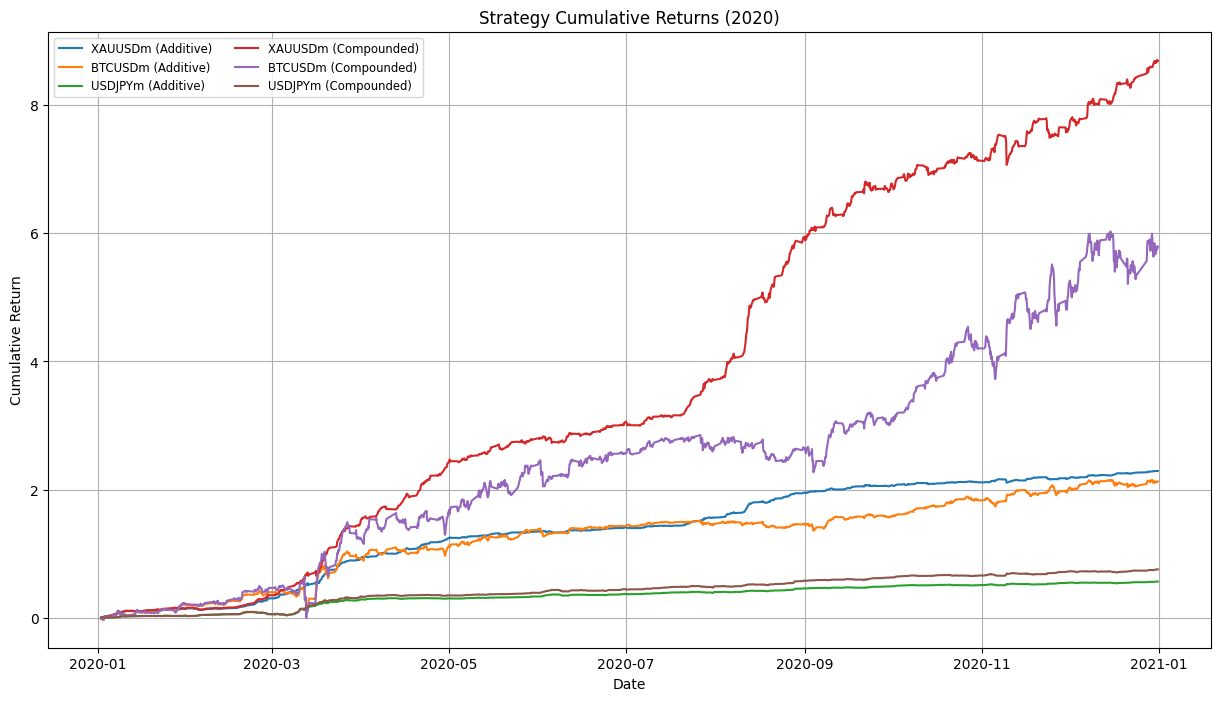

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Select your test window (make sure your index is datetime!)
data = res.dropna().loc["2020-01-01":"2021-01-01"]

# 2) Option A — additive cumulative returns (just sum of period returns)
cum_add = data.cumsum()

# 3) Option B — compounded growth: (1+returns).cumprod()
cum_comp = (1 + data).cumprod() - 1

# 4) Plot both for comparison
plt.figure(figsize=(15,8))
for df, label in [(cum_add, "Additive"), (cum_comp, "Compounded")]:
    for col in df.columns:
        plt.plot(df.index, df[col], label=f"{col} ({label})")

plt.title("Strategy Cumulative Returns (2020)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(ncol=2, fontsize="small")
plt.grid(True)
plt.show()


<Axes: xlabel='time'>

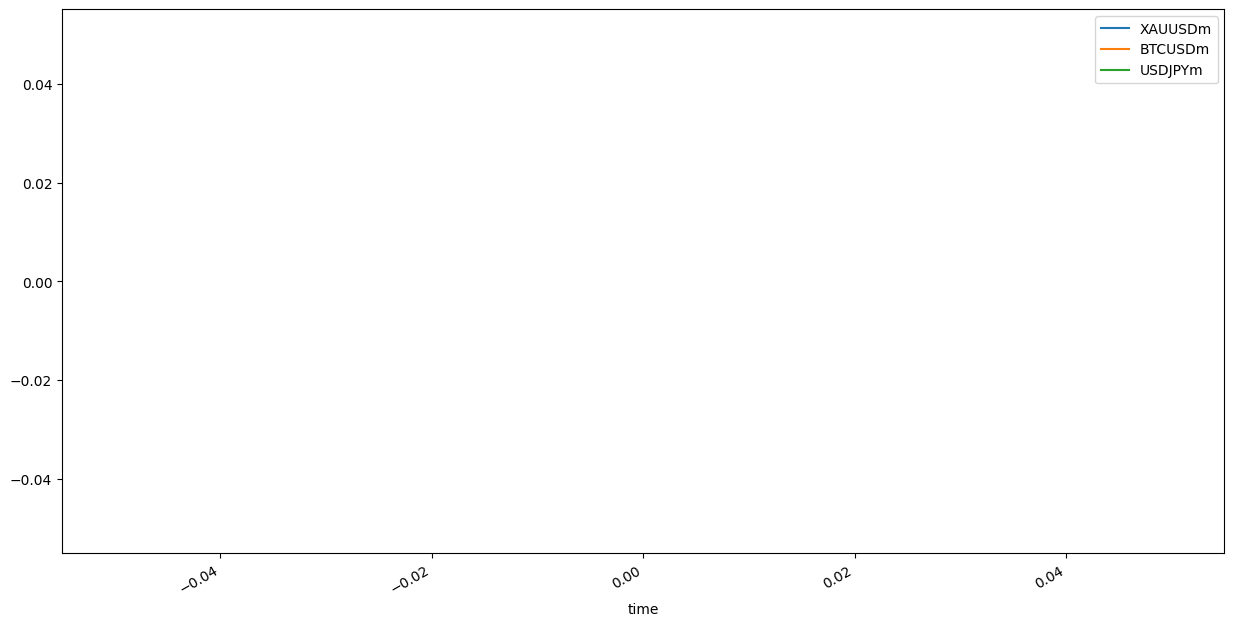

In [16]:
'''
# Display cumulative returns of the strategies on the test set
data = res.dropna().loc["2020-01":"2021-01"]
data.cumsum().plot(figsize=(15,8))
'''

### 16.2.3. Apply portfolio management technics

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.24990970915136865
            Iterations: 2
            Function evaluations: 8
            Gradient evaluations: 2
[0.334 0.333 0.333]
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')



    -----------------------------------------------------------------------------
    Beta: nan 	 Alpha: nan %	     Sharpe: 1.827 	 Sortino: 0.156
  -----------------------------------------------------------------------------
    VaR: 0.24 %	 cVaR: 0.41 % 	     VaR/cVaR: 1.686 	 drawdown: 13.52 %
  -----------------------------------------------------------------------------


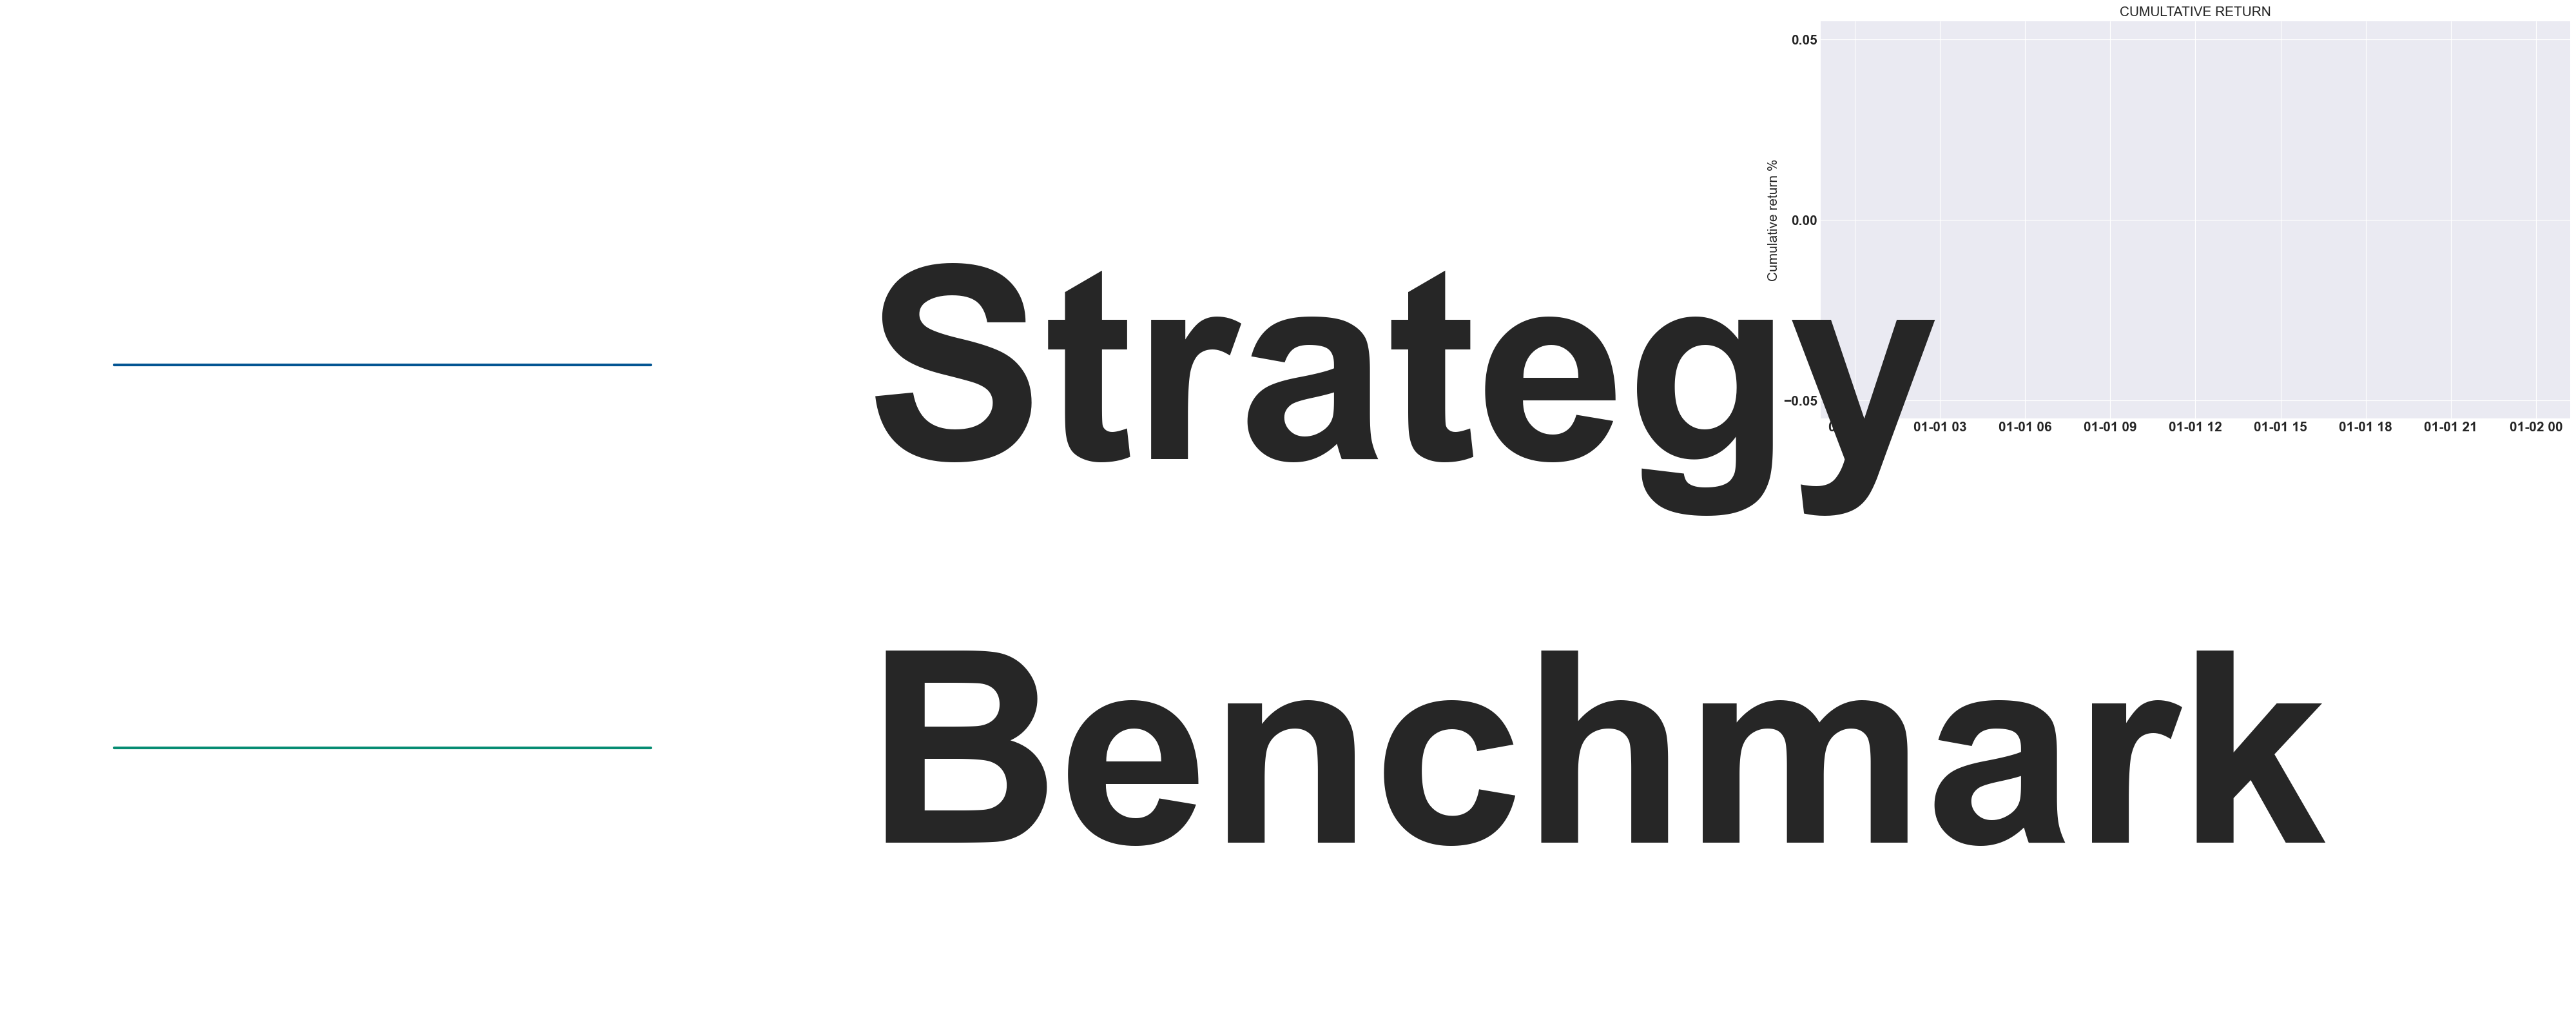

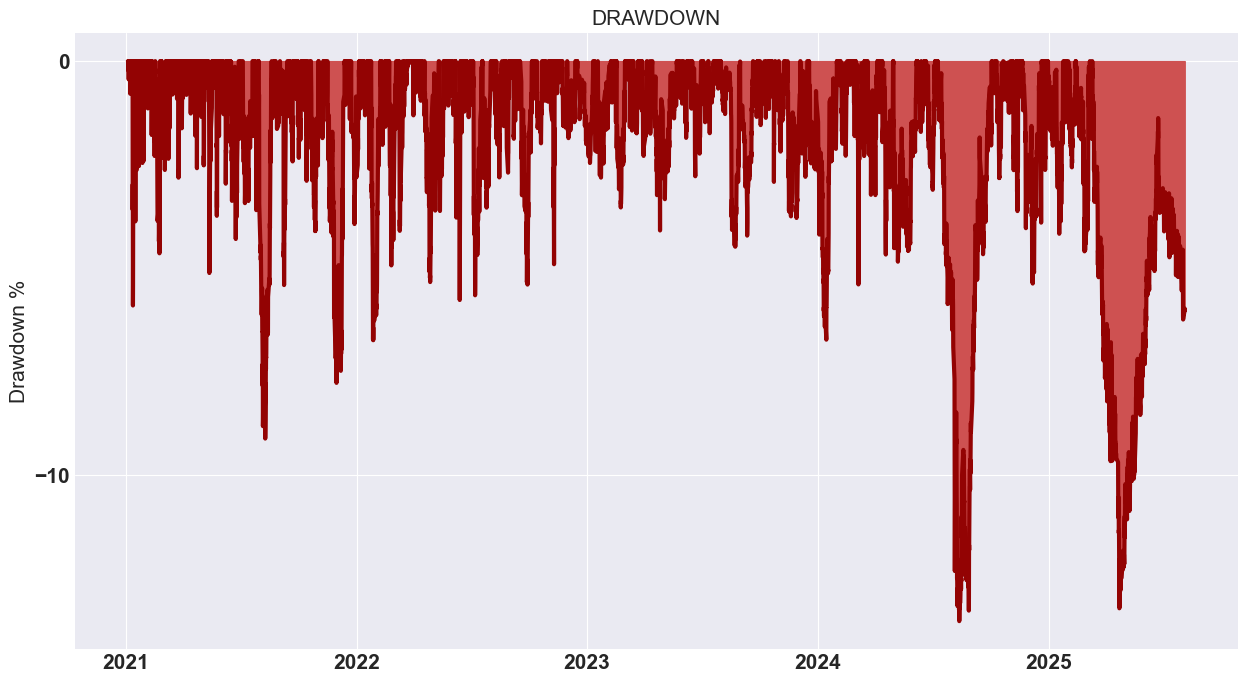

In [33]:

import matplotlib.pyplot as plt

from scipy.optimize import minimize
import numpy as np
import pandas as pds
import yfinance as yf

from quantreo.portfolio import *
data = res.dropna().loc["2020-01":"2021-01"]
val = res.dropna().loc["2021-01":]

X = optimization_portfolio(MV_criterion, data)

print(np.round(X,3))

spread = 0.00019
low_portfolio = np.multiply(low_assets,np.transpose(X)).sum(axis=1)
high_portfolio = np.multiply(high_assets,np.transpose(X)).sum(axis=1)


# Compute the cumulative return of the portfolio (CM)
portfolio_return_test = np.multiply(data,np.transpose(X)).sum(axis=1)
portfolio_return_MV = np.multiply(val,np.transpose(X)).sum(axis=1)

import yfinance as yf
backtest_dynamic_portfolio(portfolio_return_MV)

### 14.3.1. Optimal take profit

In [34]:
def find_best_tp(tp):
    tp = tp/100
    
    # Create the portfolio
    pf = pd.concat((low_portfolio, portfolio_return_test,high_portfolio), axis=1).dropna()-spread
    pf.columns = ["low", "Return", "high"]

    # Apply the tp
    pf["Return"] = np.where(pf["high"].values>tp, tp, pf["Return"].values)
    pf["Return"] = np.where(pf["Return"].values>tp, tp, pf["Return"].values)
    down = pf["Return"].values
    down = down[down<0]
    
    # Return sharpe raatio
    return np.sqrt(252)*pf["Return"].mean()/down.std()

pd.DataFrame([find_best_tp(tp) for tp in np.linspace(0.5,10,30)],  index=np.linspace(0.5,10,30), columns=["Sharpe"])

,Sharpe
0.500000,3.956011
0.827586,2.964970
1.155172,3.055405
1.482759,3.222112
1.810345,3.174957
2.137931,3.009547
2.465517,2.988266
2.793103,2.949434
3.120690,2.941083
3.448276,2.963941


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')



    -----------------------------------------------------------------------------
    Beta: nan 	 Alpha: nan %	     Sharpe: 2.481 	 Sortino: 0.187
  -----------------------------------------------------------------------------
    VaR: -0.07 %	 cVaR: 0.07 % 	     VaR/cVaR: -1.077 	 drawdown: 7.64 %
  -----------------------------------------------------------------------------


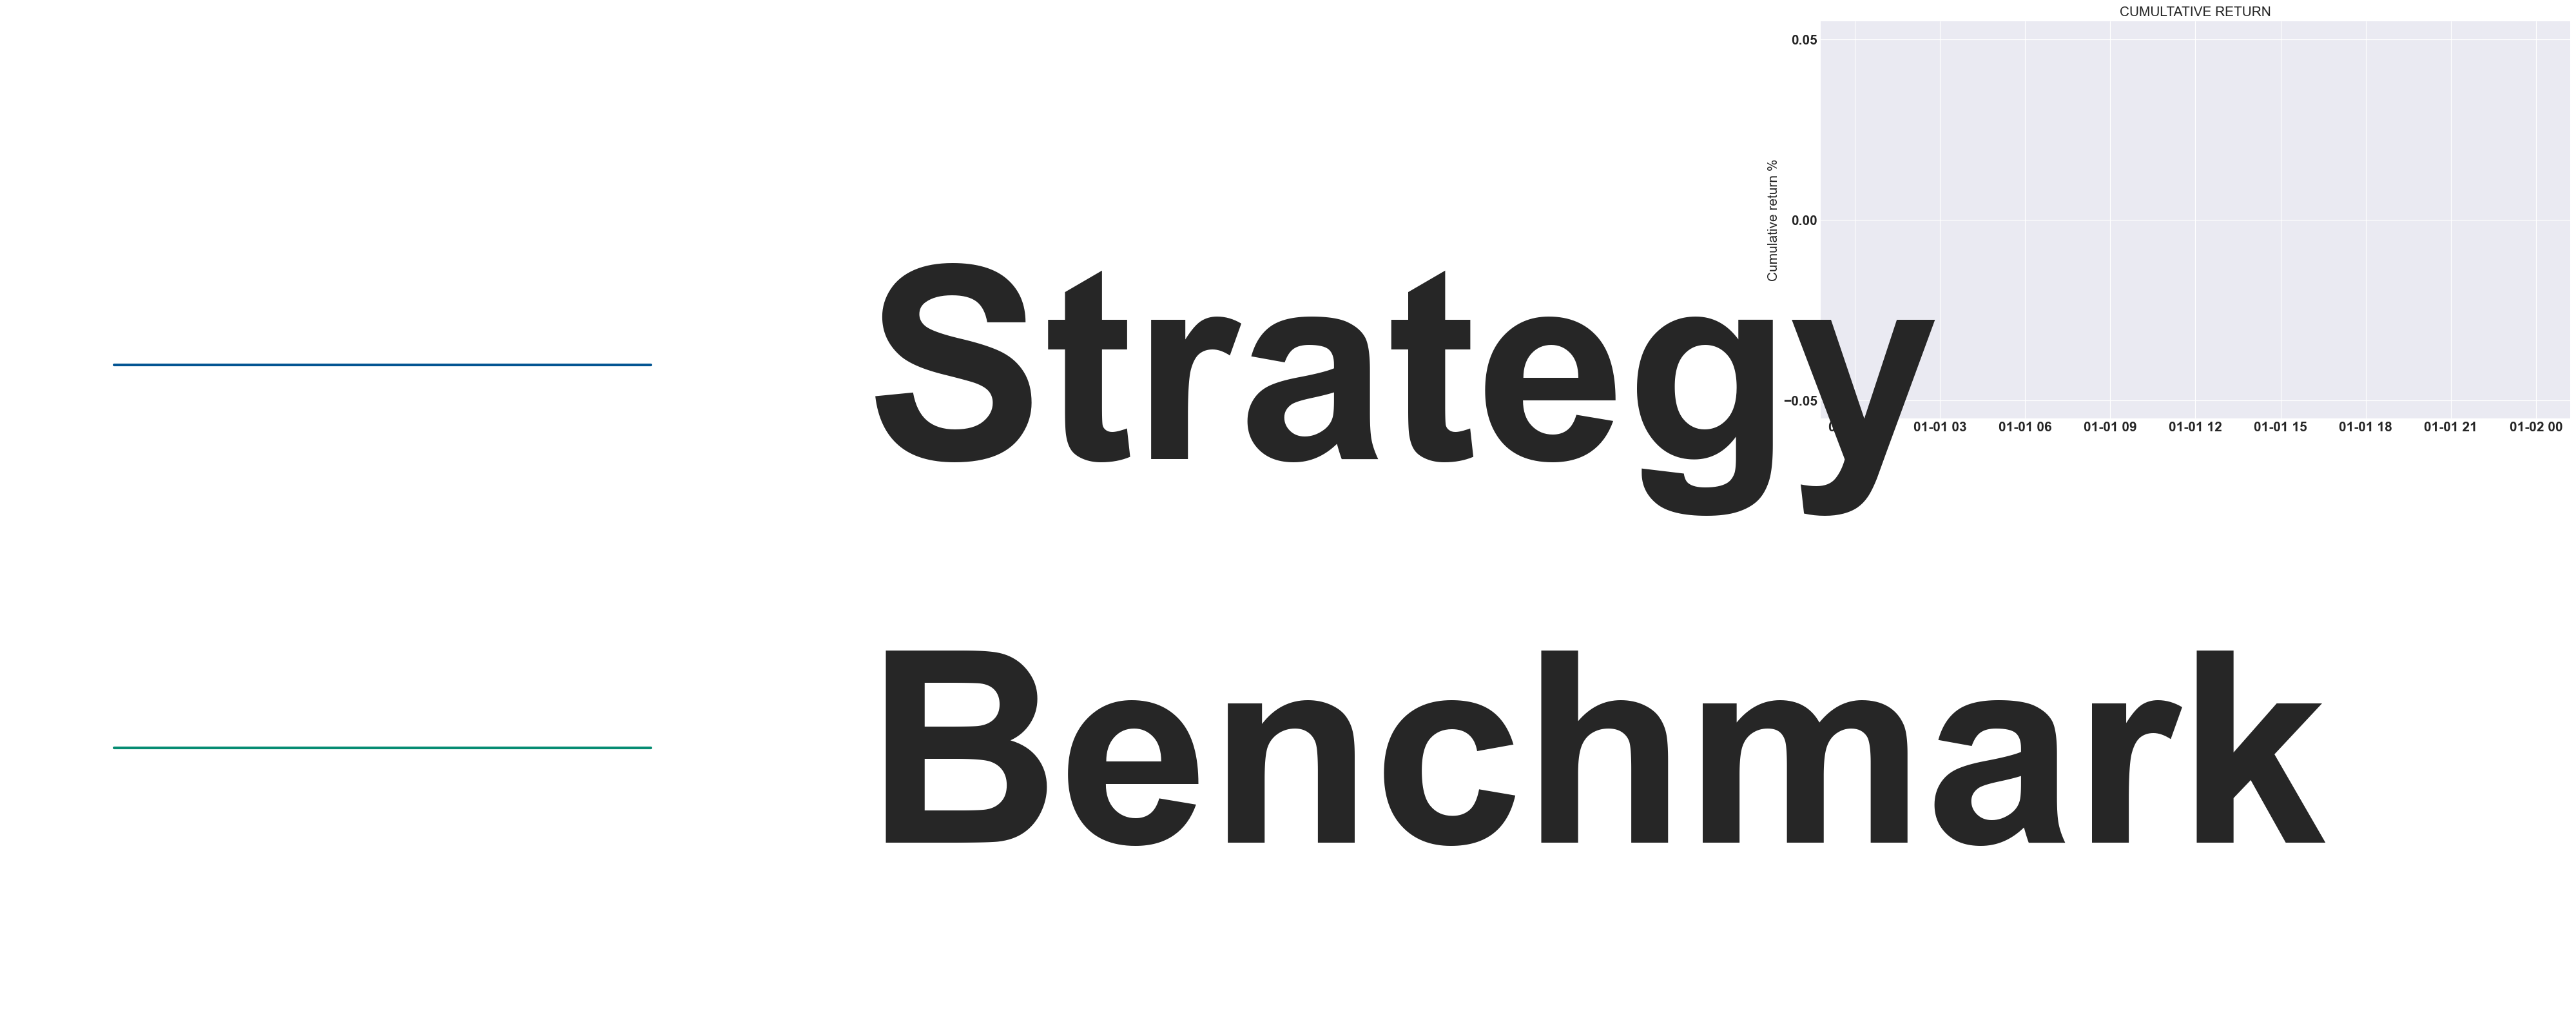

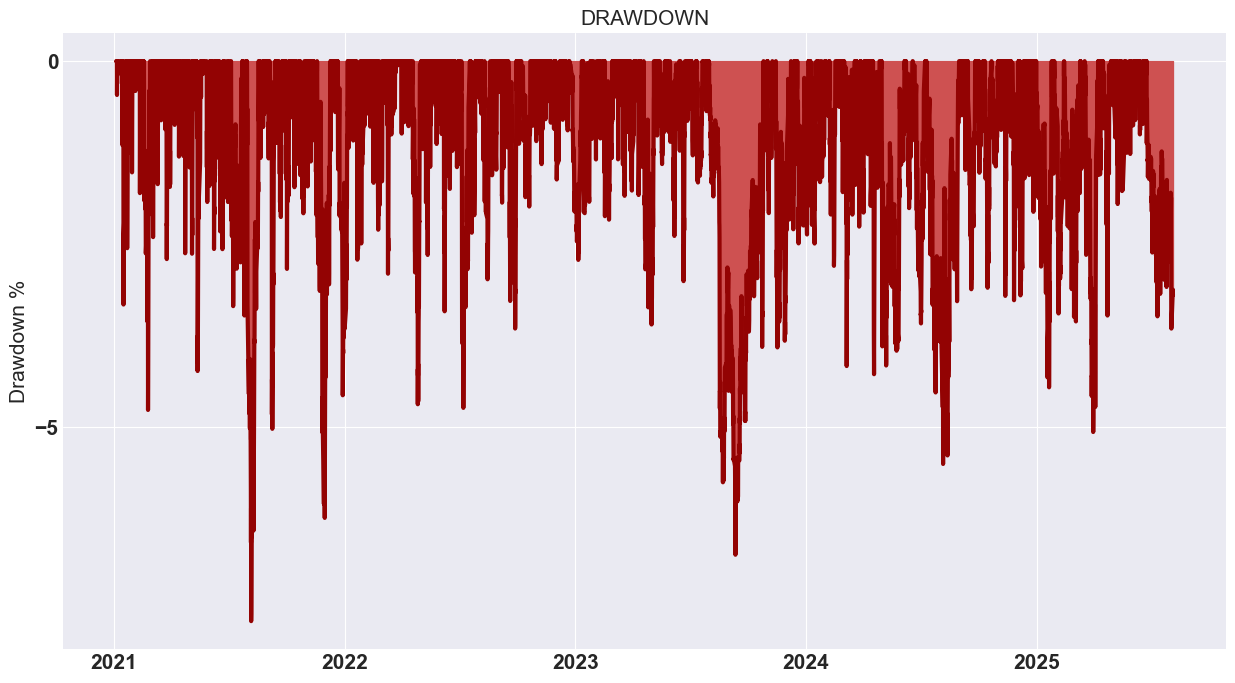

In [35]:
tp = 0.5/100
pf = pd.concat((low_portfolio, portfolio_return_MV,high_portfolio), axis=1).dropna()-spread
pf.columns = ["low", "Return", "high"]

pf["Return"] = np.where(pf["high"].values>tp, tp, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values>tp, tp, pf["Return"].values)

backtest_dynamic_portfolio(pf["Return"])

### 16.3.2. Optimal stop loss

In [36]:
def find_best_sl(sl):
    sl = sl/100
    
    # Create the portfolio
    pf = pd.concat((low_portfolio, portfolio_return_test,high_portfolio), axis=1).dropna()-spread
    pf.columns = ["low", "Return", "high"]

    # Apply the tp
    pf["Return"] = np.where(pf["low"].values<-sl, -sl, pf["Return"].values)
    pf["Return"] = np.where(pf["Return"].values<-sl, -sl, pf["Return"].values)
    
    # Return sharpe raatio
    return np.sqrt(252)*pf["Return"].mean()/pf["Return"].std()

pd.DataFrame([find_best_sl(sl) for sl in np.linspace(1,10,30)],  index=np.linspace(1,10,30), columns=["Sharpe"])

,Sharpe
1.000000,1.657729
1.310345,2.206745
1.620690,2.404367
1.931034,2.338230
2.241379,2.212557
2.551724,2.319000
2.862069,2.457857
3.172414,2.626110
3.482759,2.541583
3.793103,2.780530


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')



    -----------------------------------------------------------------------------
    Beta: nan 	 Alpha: nan %	     Sharpe: 1.165 	 Sortino: 0.096
  -----------------------------------------------------------------------------
    VaR: 0.59 %	 cVaR: 0.76 % 	     VaR/cVaR: 1.282 	 drawdown: 22.7 %
  -----------------------------------------------------------------------------


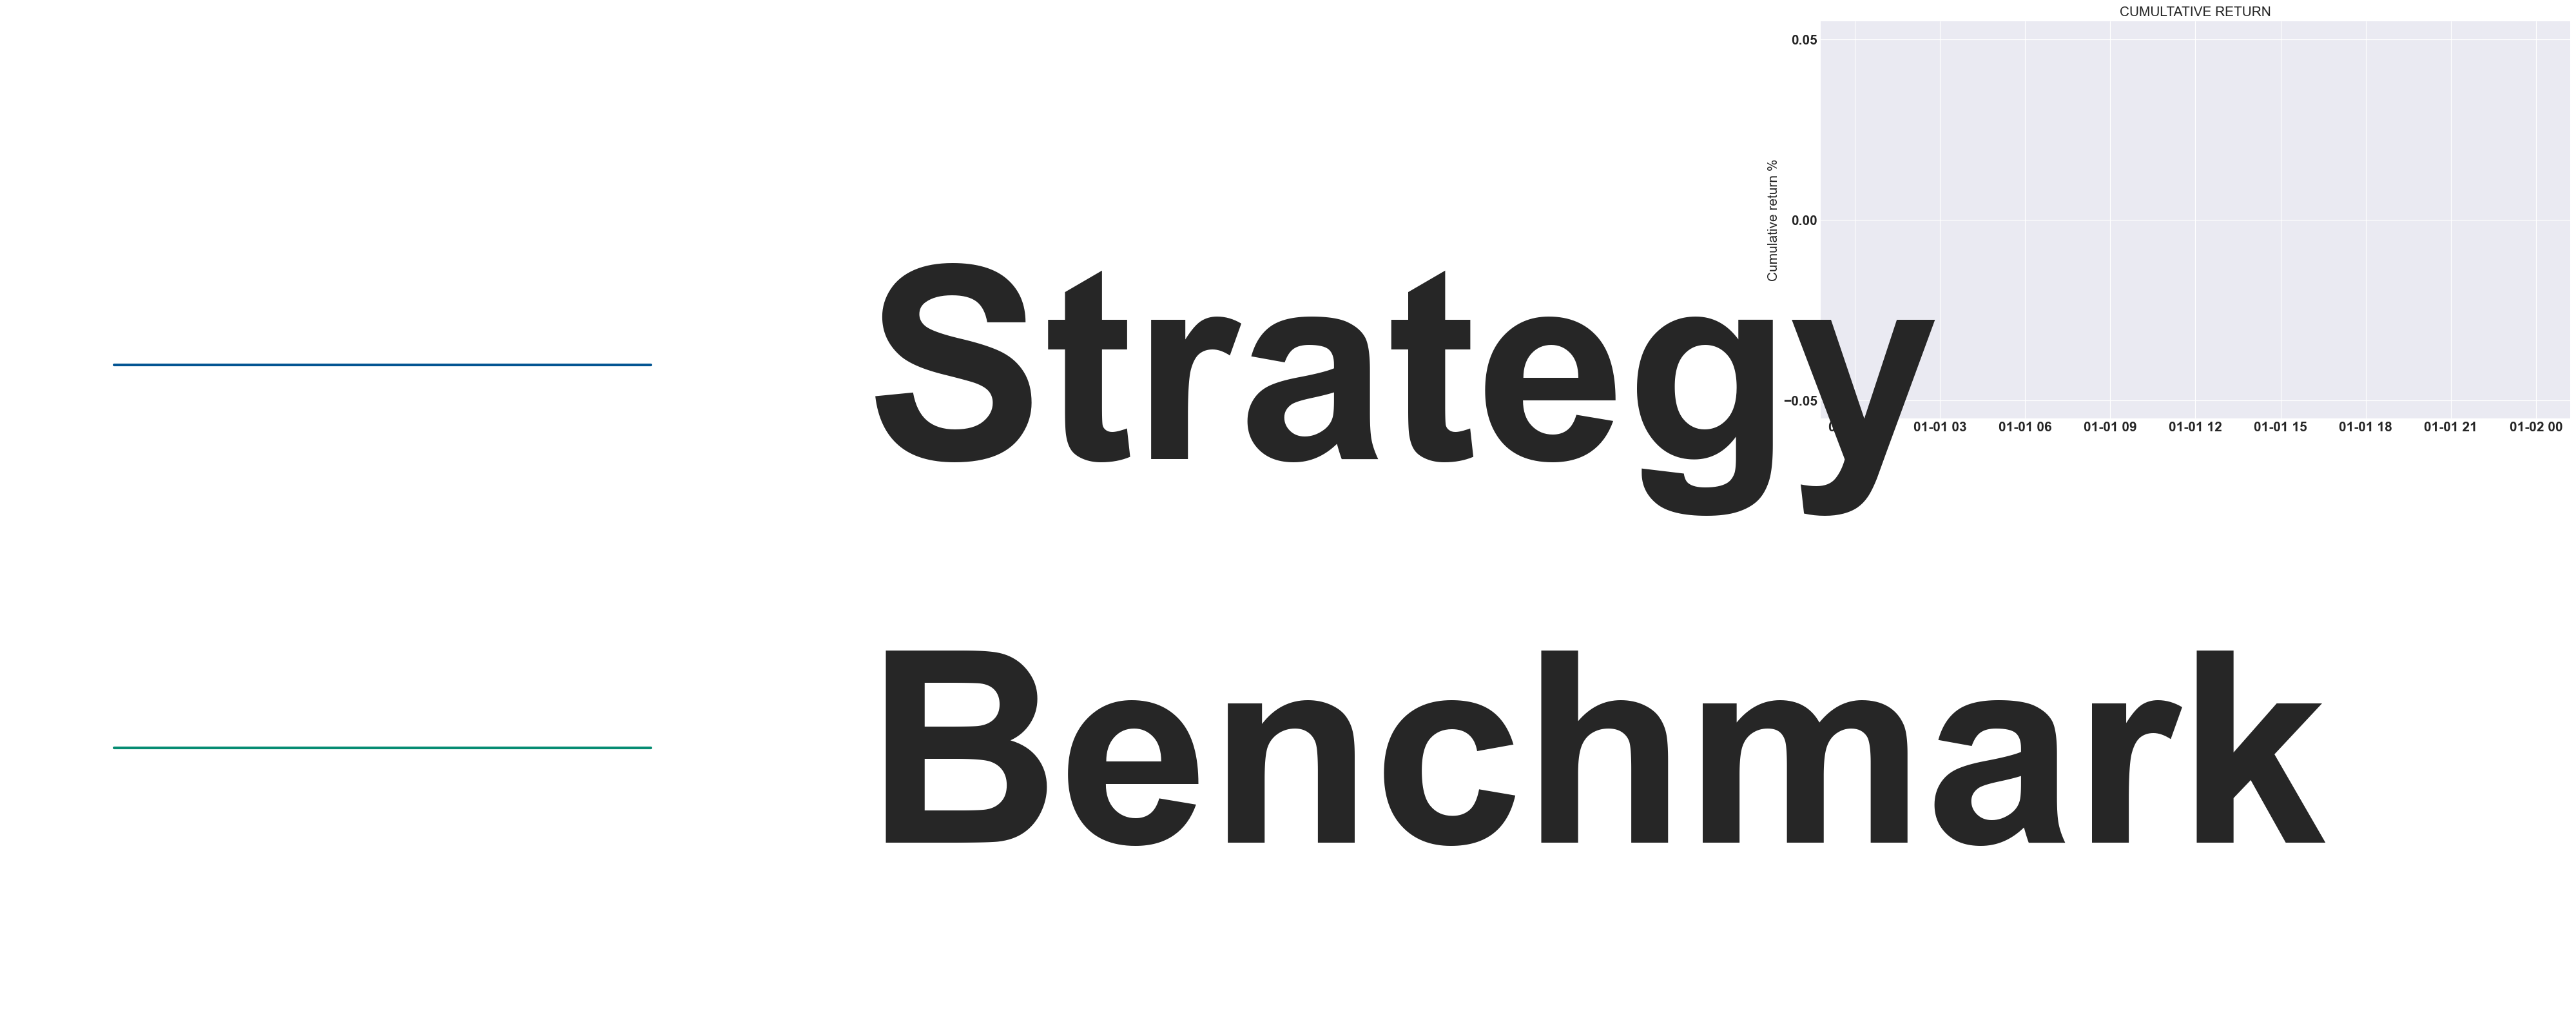

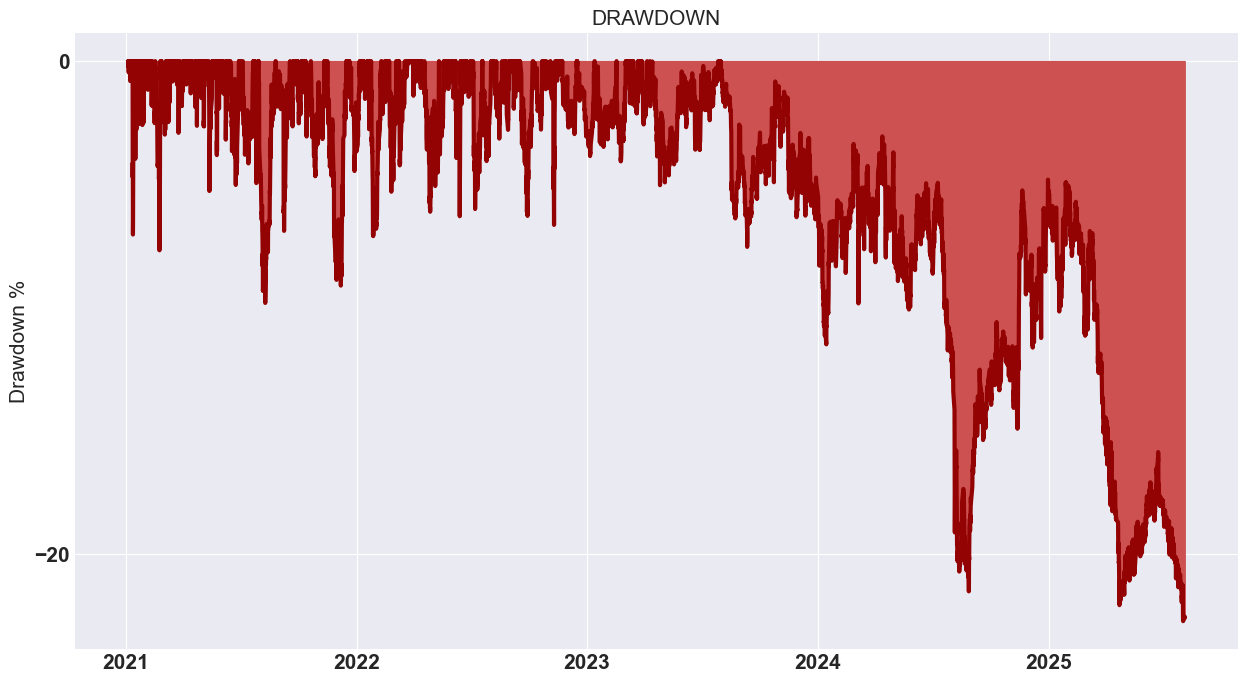

In [37]:
sl = 3.79/100
pf = pd.concat((low_portfolio, portfolio_return_MV,high_portfolio), axis=1).dropna()-spread

pf.columns = ["low", "Return", "high"]
pf["Return"] = np.where(pf["low"].values<-sl, -sl, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values<-sl, -sl, pf["Return"].values)


backtest_dynamic_portfolio(pf["Return"])

### 14.3.3. Optimal leverage

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')



    -----------------------------------------------------------------------------
    Beta: nan 	 Alpha: nan %	     Sharpe: 1.219 	 Sortino: 0.105
  -----------------------------------------------------------------------------
    VaR: 0.83 %	 cVaR: 1.09 % 	     VaR/cVaR: 1.31 	 drawdown: 31.73 %
  -----------------------------------------------------------------------------


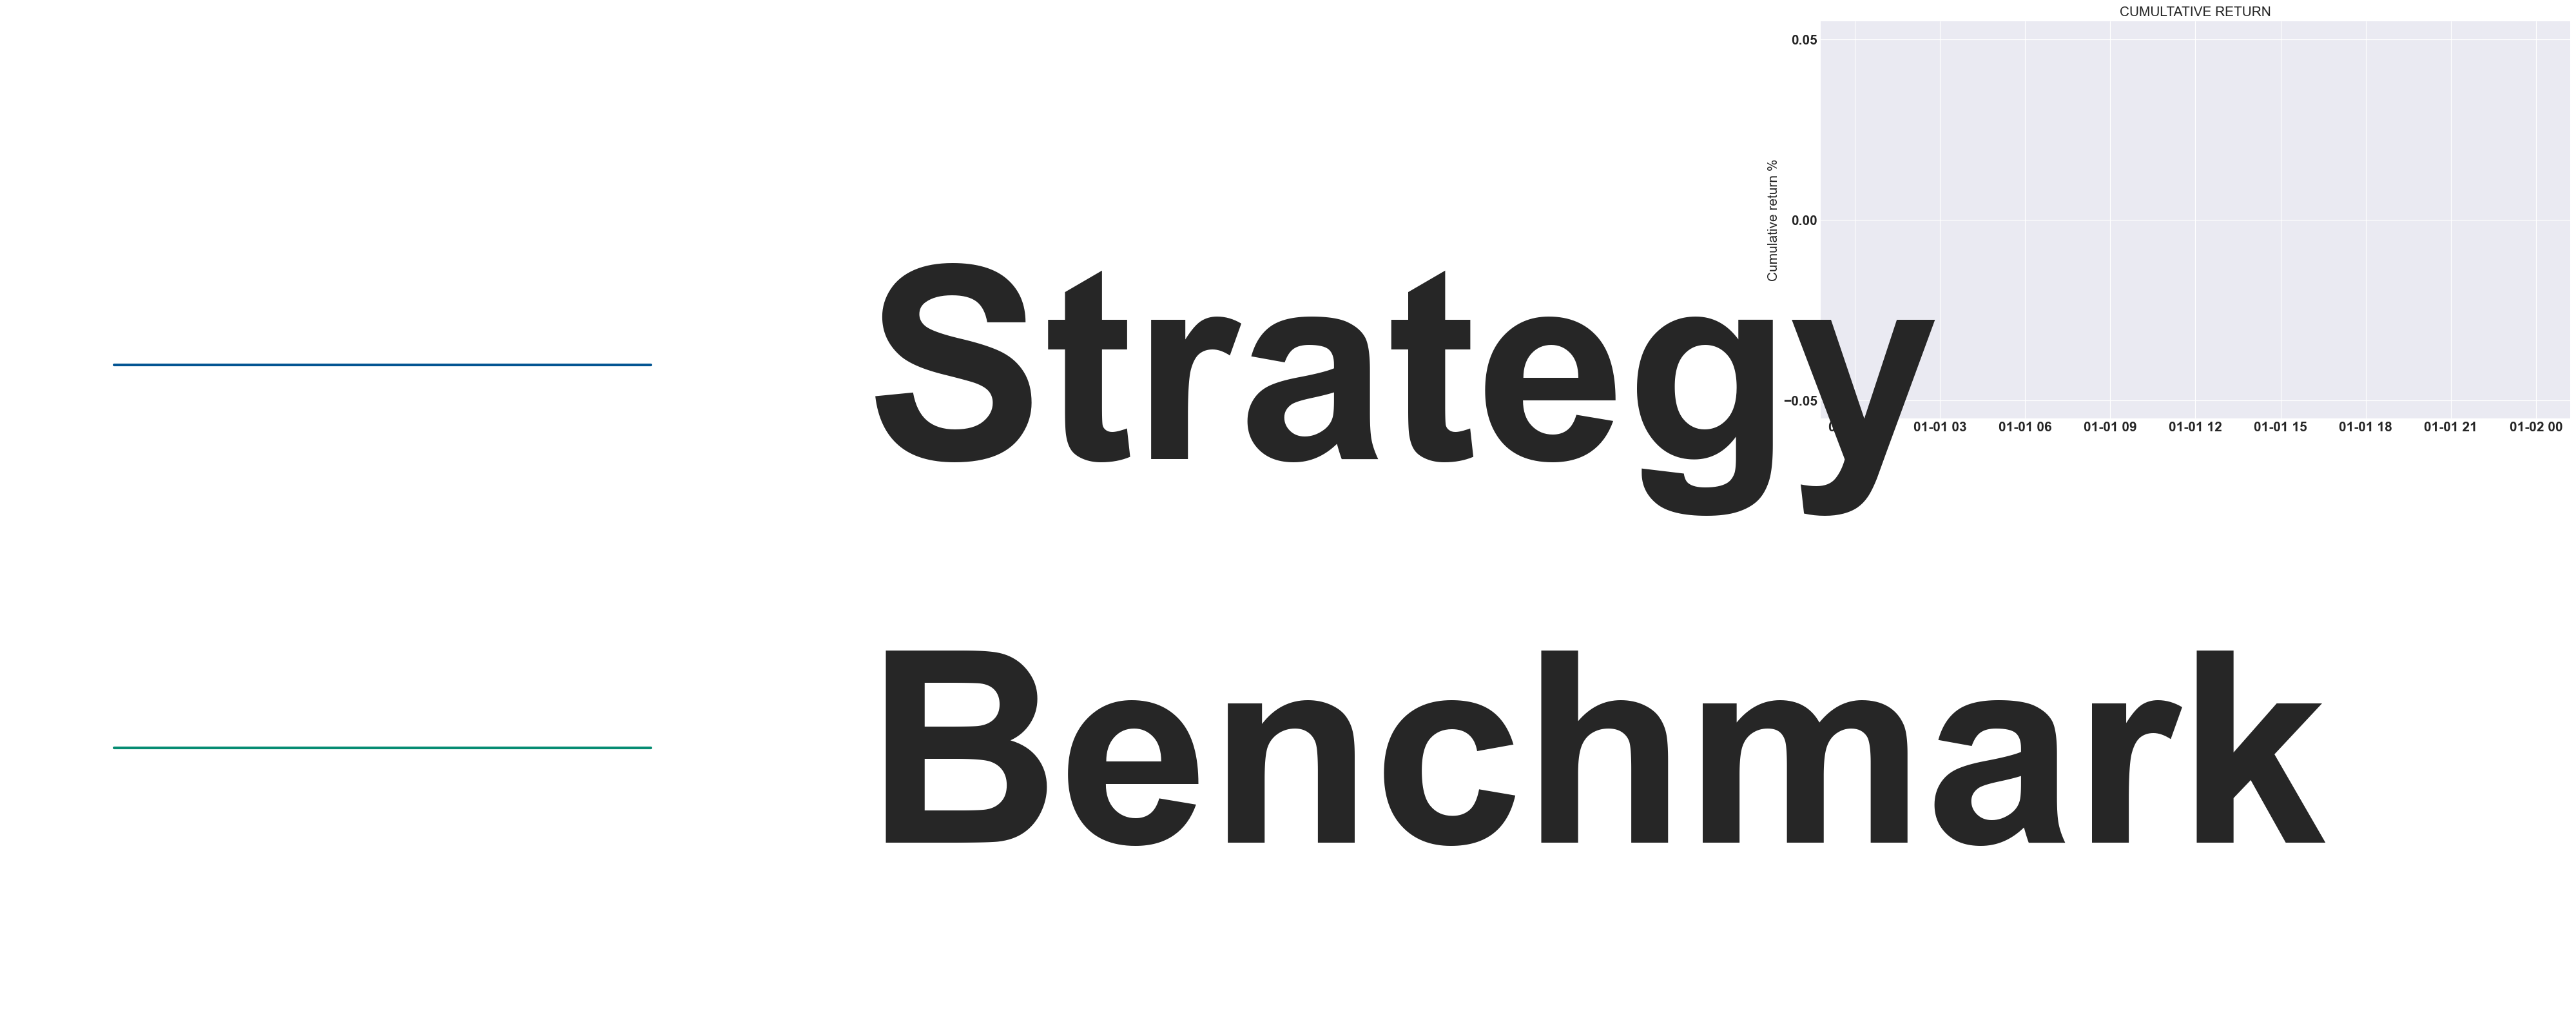

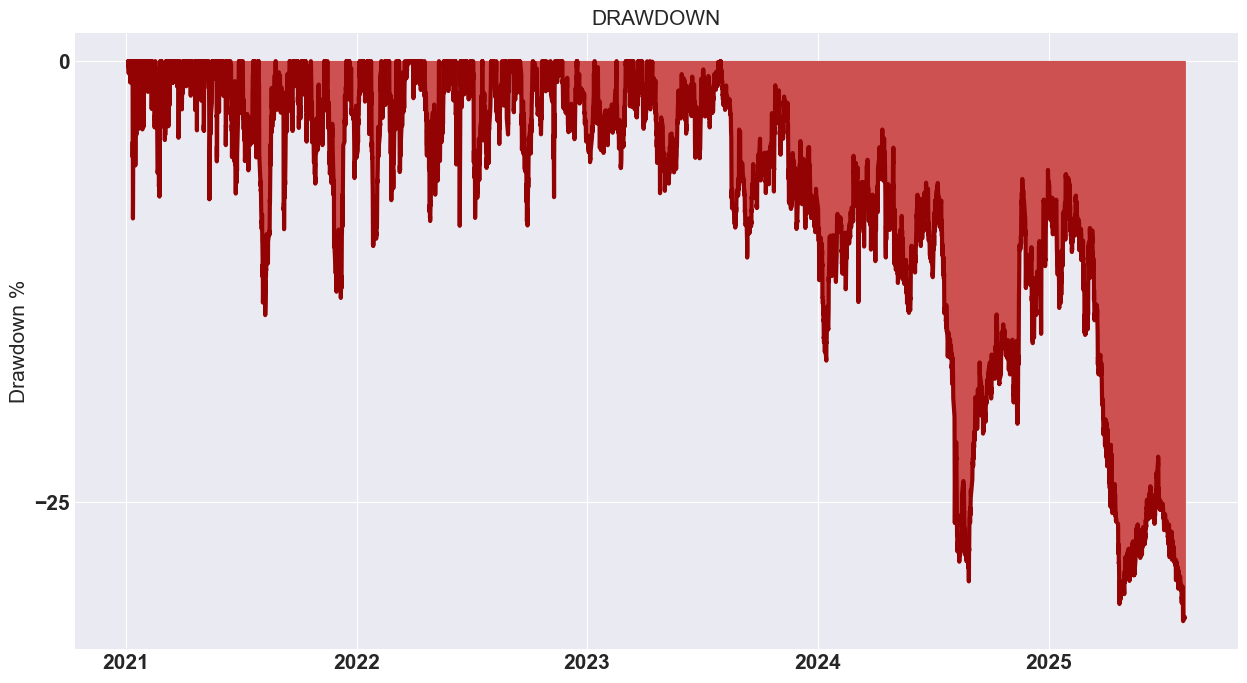

In [38]:
leverage = 1.5
tp =0.5
sl = 3.79
pf = (pd.concat((low_portfolio, portfolio_return_MV,high_portfolio), axis=1).dropna()-spread)*leverage
pf.columns = ["low", "Return", "high"]

pf["Return"] = np.where(pf["high"].values>tp, tp, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values>tp, tp, pf["Return"].values)
pf["Return"] = np.where(pf["low"].values<-sl, -sl, pf["Return"].values)
pf["Return"] = np.where(pf["Return"].values<-sl, -sl, pf["Return"].values)

# Plot the CM
backtest_dynamic_portfolio(pf["Return"])

Why has the performance does not grown since 06-2021? There are some explanations. The period's volatility is less than the other, and the strategy does not work on it, or the weight of the algorithm needs to be adjusted because the market situation has evolved.

Congratulations!

You have read the whole book. It is normal if you do not have to understand all the notions. To a better understanding, I advise you to use your news skills in your projects.
